# Tutorial 5 — Metacognitive Bias

Tests whether each measure is sensitive to confidence *bias* — a systematic
tendency to use high or low ratings regardless of accuracy. Uses the Xue et al.
(2021) recoding method from Rahnev (2025) Supp Tables 6–8.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from metasignal import stdpy

MEASURE_NAMES = [
    "meta-d'", "AUC2", "Gamma", "Phi", "DeltaConf",
    "M-Ratio", "AUC2-Ratio", "Gamma-Ratio", "Phi-Ratio", "DeltaConf-Ratio",
    "M-Diff", "AUC2-Diff", "Gamma-Diff", "Phi-Diff", "DeltaConf-Diff",
    "metaNoise", "metaUncertainty", "d'", "c", "mean_conf",
    "logL", "AIC", "BIC", "AICc", "k", "n",
]
N_MEAS = 26
n_ratings = 4

def simulate_subject(seed, n_trials=300, accuracy=0.78):
    r = np.random.default_rng(seed)
    stim    = r.choice([0, 1], n_trials)
    resp    = np.where(r.random(n_trials) < accuracy, stim, 1 - stim)
    correct = stim == resp
    conf    = np.where(
        correct,
        r.integers(3, n_ratings + 1, n_trials),
        r.integers(1, 3, n_trials),
    )
    return stim, resp, conf

n_subjects = 25
dataset    = [simulate_subject(i) for i in range(n_subjects)]
print(f"Simulated {n_subjects} subjects")


Simulated 25 subjects


## The Xue recoding function

| Recode | Effect | Mechanism |
| --- | --- | --- |
| 1 | High-confidence bias | Subtract 1 from all ratings; bump minimum up by 1 |
| 2 | Low-confidence bias  | Replace maximum with max − 1 |

In [2]:
def xue_recode(conf, rtype):
    c = conf.copy().astype(float)
    valid = c[~np.isnan(c)]
    if len(np.unique(valid)) < 3:
        return np.full_like(c, np.nan)
    if rtype == 1:
        c -= 1
        cmin = np.nanmin(c)
        c[c == cmin] = cmin + 1
    elif rtype == 2:
        cmax = np.nanmax(c)
        c[c == cmax] = cmax - 1
    return c

ex = np.array([1, 2, 3, 4, 4, 3, 2, 1])
print("Original : ", ex)
print("Recode 1 : ", xue_recode(ex, 1).astype(int))
print("Recode 2 : ", xue_recode(ex, 2).astype(int))


Original :  [1 2 3 4 4 3 2 1]
Recode 1 :  [1 1 2 3 3 2 1 1]
Recode 2 :  [1 2 3 3 3 3 2 1]


## Compute measures under both recodings

In [3]:
n_ratings_rc = n_ratings - 1
bias = np.full((n_subjects, 2, N_MEAS), np.nan)

for s_idx, (stim, resp, conf) in enumerate(dataset):
    for rt in (1, 2):
        conf_rc = xue_recode(conf, rt)
        valid   = ~np.isnan(conf_rc)
        bias[s_idx, rt - 1] = stdpy.compute_all_measures(
            stim[valid], resp[valid], conf_rc[valid].astype(int),
            n_ratings=n_ratings_rc,
        )

print("Bias array shape:", bias.shape)


Bias array shape: (25, 2, 26)


## Test recode2 − recode1 against zero

In [4]:
SKIP = {"d'", "c"}

def ttest_1samp(data):
    x = np.asarray(data, float)[~np.isnan(np.asarray(data, float))]
    n = len(x)
    if n < 2: return np.nan, np.nan, np.nan, np.nan
    t, p = stats.ttest_1samp(x, 0)
    return t, n - 1, p, t / np.sqrt(n)

delta = bias[:, 1, :] - bias[:, 0, :]

print(f"{'Measure':<20} {'t':>8} {'p':>10} {'d':>9} {'sig':>4}")
print("-" * 56)
for m, name in enumerate(MEASURE_NAMES):
    if name in SKIP: continue
    t, df, p, d = ttest_1samp(delta[:, m])
    if np.isnan(t): continue
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"{name:<20} {t:8.3f} {p:10.4f} {d:9.3f} {stars:>4}")


Measure                     t          p         d  sig
--------------------------------------------------------
meta-d'                 0.928     0.3628     0.186     
Phi                    41.907     0.0000     8.381  ***
DeltaConf               2.097     0.0467     0.419    *
M-Ratio                 0.932     0.3606     0.186     
AUC2-Ratio            -14.291     0.0000    -2.858  ***
Gamma-Ratio            22.282     0.0000     4.456  ***
Phi-Ratio              14.642     0.0000     2.928  ***
DeltaConf-Ratio        19.075     0.0000     3.815  ***
M-Diff                  0.928     0.3628     0.186     
AUC2-Diff             -15.399     0.0000    -3.080  ***
Gamma-Diff             39.625     0.0000     7.925  ***
Phi-Diff               37.911     0.0000     7.582  ***
DeltaConf-Diff          6.852     0.0000     1.370  ***
metaNoise              -3.678     0.0012    -0.736   **
mean_conf              97.096     0.0000    19.419  ***
logL                   72.770     0.0000    14.

## Visualise bias effect

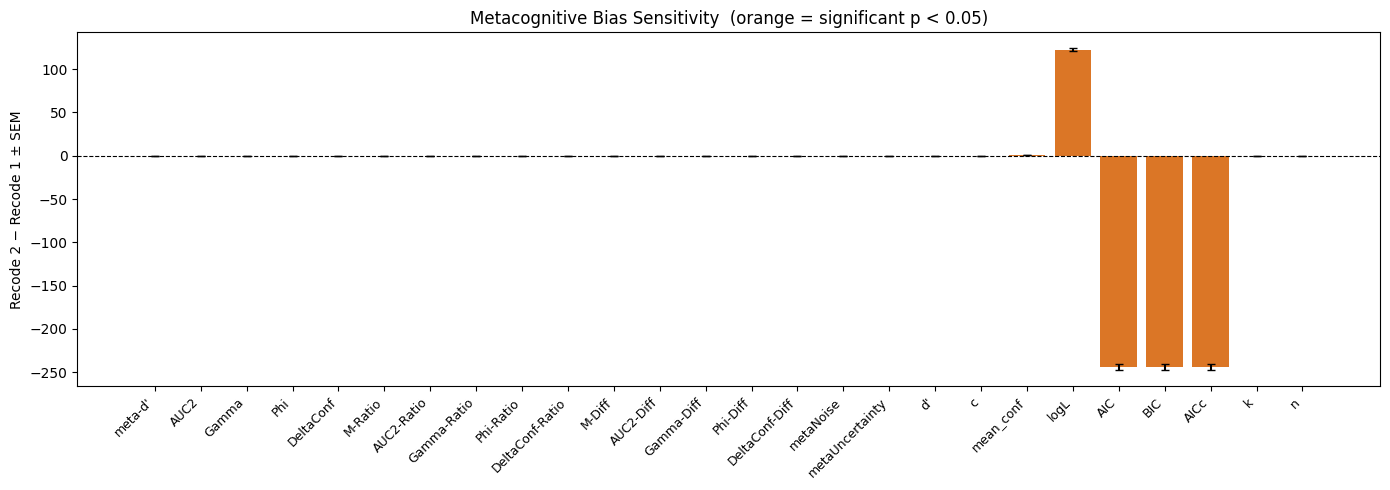

In [5]:
means = np.nanmean(delta, axis=0)
n_ok  = np.sum(~np.isnan(delta), axis=0)
sems  = np.nanstd(delta, axis=0, ddof=1) / np.sqrt(np.maximum(n_ok, 1))

ps = [ttest_1samp(delta[:, m])[2] for m in range(N_MEAS)]
colors = ["#d55e00" if (p is not None and not np.isnan(p) and p < 0.05) else "#999999"
          for p in ps]

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(N_MEAS)
ax.bar(x, means, yerr=sems, color=colors, alpha=0.85, capsize=3)
ax.axhline(0, color="k", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(MEASURE_NAMES, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Recode 2 − Recode 1 ± SEM")
ax.set_title("Metacognitive Bias Sensitivity  (orange = significant p < 0.05)")
plt.tight_layout()
plt.show()
